
Links
* [KDNugget](https://www.kdnuggets.com/linear-regression-from-scratch-with-numpy)
* 2 Ways to Train Linear Regression [Part 1](https://medium.com/analytics-vidhya/2-ways-to-train-a-linear-regression-model-part-1-e643dbef3df1) and [Part 2](https://medium.com/analytics-vidhya/2-ways-to-train-a-linear-regression-model-part-2-fdeb50fc58fa)
* [Linear Regression Made Simple, Step by Step Tutorial](https://utsavdesai26.medium.com/linear-regression-made-simple-a-step-by-step-tutorial-fb8e737ea2d9)


In [1]:
from abc import ABC
from abc import abstractmethod

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from numpy.typing import NDArray, ArrayLike
from sklearn.metrics import mean_squared_error as sklearn_mean_squared_error
from sklearn.metrics import r2_score as sklearn_r2_score

class LinearRegressionBase(ABC):
    # Shape (n_features, )
    slope_coeficients:NDArray[float] = np.array([])
    # float
    intersection:float = 0.
    
    @abstractmethod
    def fit(self, X,Y):
        # X has shape (n_samples, n_features)
        pass

    def predict(self, X:NDArray) -> NDArray:
        # X has shape (n_samples, n_features)
        if X.shape[1] != self.slope_coeficients.size:
            raise ValueError(f"X has invalid n_features, slope has {self.slope_coeficients.size}, X {X.shape[1]}")
        return (self.slope_coeficients * X).sum(axis=1) + self.intersection 

class Metrics:
    @staticmethod
    def mse(y_true:NDArray, y_pred:NDArray) -> np.float64:
        n = y_true.size
        return ((y_true - y_pred)**2).sum() / n

    @staticmethod
    def r_sq_score(y_true:NDArray, y_pred:NDArray) -> np.float64:
        sum_sq_diff = ((y_true - y_pred)**2).sum() # "squared residuals"
        gt_mean = np.mean(y_true)
        sum_sq_of_gt = ((y_true - gt_mean)**2).sum() # proportional to variance 
        return 1 - sum_sq_diff / sum_sq_of_gt
        

class SKLearnLinearRegression(LinearRegressionBase):
    def __init__(self):
        self.regression = LinearRegression()

    def fit(self, X,Y):
        # X has shape (n_samples, n_features)
        self.regression.fit(X,Y)
        self.slope_coeficients = self.regression.coef_
        self.intersection = self.regression.intercept_
        

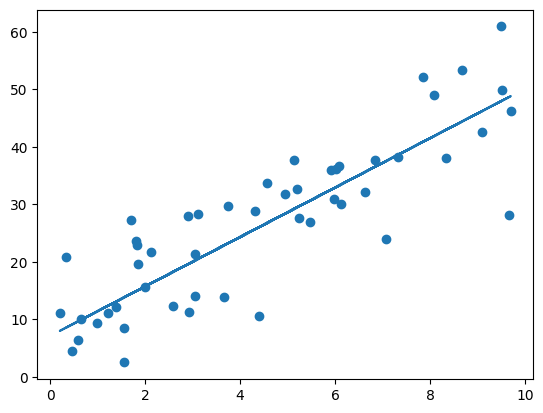

In [2]:
np.random.seed(42)

def noisy_linear(gradient:float, y_inter:float, mean:float=.5, std:float=1.8, 
                 num_elements:int=50, xmin=0, xmax=10
                ) -> tuple[np.ndarray, np.ndarray]:
    # X = np.linspace(xmin, xmax, num=num_elements)
    X = np.random.uniform(low=0, high=xmax, size=num_elements)
    noise = std * np.random.randn(num_elements) + mean
    Y = gradient * X + y_inter + noise
    return X[:,None],Y

gradient, y_inter = 4.3, 7.1
std = 8
X,Y = noisy_linear(gradient, y_inter, std=std )
X_test, Y_test = noisy_linear(gradient, y_inter, std=std, num_elements=25)
plt.scatter(X,Y)
# plt.scatter(X_test, Y_test)
plt.plot(X, gradient*X+y_inter)
plt.show()

Tests

In [3]:
skLin = SKLearnLinearRegression()
skLin.fit(X,Y)
sklearn_preds = skLin.regression.predict(X_test)
my_preds = skLin.predict(X_test)

my_mse = Metrics.mse(Y_test, my_preds)
my_r2 = Metrics.r_sq_score(Y_test, my_preds)
sk_r2 = sklearn_r2_score(Y_test, my_preds)
sklearn_mse = sklearn_mean_squared_error(Y_test, sklearn_preds)

assert np.shape(my_preds) == np.shape(sklearn_preds), 'Prediction shape not the same as Sklean, '\
    f'{np.shape(my_preds)} != {np.shape(sklearn_preds)}'
assert np.allclose(my_preds, sklearn_preds), 'My Predictor differs to Sklearns'
assert np.isclose(my_mse, sklearn_mse), 'MSE differs between my preds and Sklean mse function'
assert np.isclose(my_r2, sk_r2), 'R**2 differs between my preds and Sklean mse function'

pred_lr = lambda x, slope, c: (slope * x).sum(axis=1) + c
train_gt_mse = Metrics.mse(Y, pred_lr(X, gradient, y_inter))
test_gt_mse = Metrics.mse(Y_test, pred_lr(X_test, gradient, y_inter))

print(f'GT Slope and Intersect; train mse {train_gt_mse:.3f}, test mse {test_gt_mse:.3f}')

GT Slope and Intersect; train mse 53.165, test mse 46.743


In [4]:
def run_linear_regression(Linear_Regressor:LinearRegressionBase, X=X, Y=Y, X_test=X_test, Y_test=Y_test):
    lin_reg = Linear_Regressor()
    lin_reg.fit(X,Y)
    lin_reg.slope_coeficients
    train_preds = lin_reg.predict(X)
    test_preds = lin_reg.predict(X_test)
    
    train_mse = Metrics.mse(Y, train_preds)
    train_r2 = Metrics.r_sq_score(Y, train_preds)
    
    test_mse = Metrics.mse(Y_test, test_preds)
    test_r2 = Metrics.r_sq_score(Y_test, test_preds)
    with np.printoptions(precision=3):
        print(f'"{Linear_Regressor.__name__}" has params '
              f'{lin_reg.slope_coeficients} and {lin_reg.intersection:.3f}\n'
              f'MSE:       train {train_mse:.3f}, test {test_mse:.3f}\n'
              f'R Squared: train {train_r2:.3f}, test {test_r2:.3f}')

In [5]:
run_linear_regression(SKLearnLinearRegression)

"SKLearnLinearRegression" has params [4.121] and 8.374
MSE:       train 52.677, test 45.146
R Squared: train 0.725, test 0.737


Closed form loop


Going to follow this equation, and then do it again with matrices

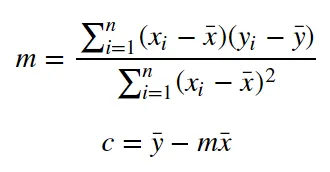!

Where x dash is the mean of X and y dash is the mean y values

In [6]:
class LinearRegressionClosedFormLoop(LinearRegressionBase):
    
    def fit(self, X,Y):
        # X has shape (n_samples, n_features)
        x_mean = np.mean(X, axis=0)
        y_mean = np.mean(Y)
        numerator = 0
        denominator = 0
        for i in range(len(Y)):
            x_diff = (X[i,:] - x_mean)
            numerator += x_diff * (Y[i] - y_mean)
            denominator += x_diff**2
        self.slope_coeficients = numerator/denominator
        self.intersection = (y_mean - self.slope_coeficients * x_mean)[0]

run_linear_regression(LinearRegressionClosedFormLoop)

"LinearRegressionClosedFormLoop" has params [4.121] and 8.374
MSE:       train 52.677, test 45.146
R Squared: train 0.725, test 0.737


Vectorized Closed Form

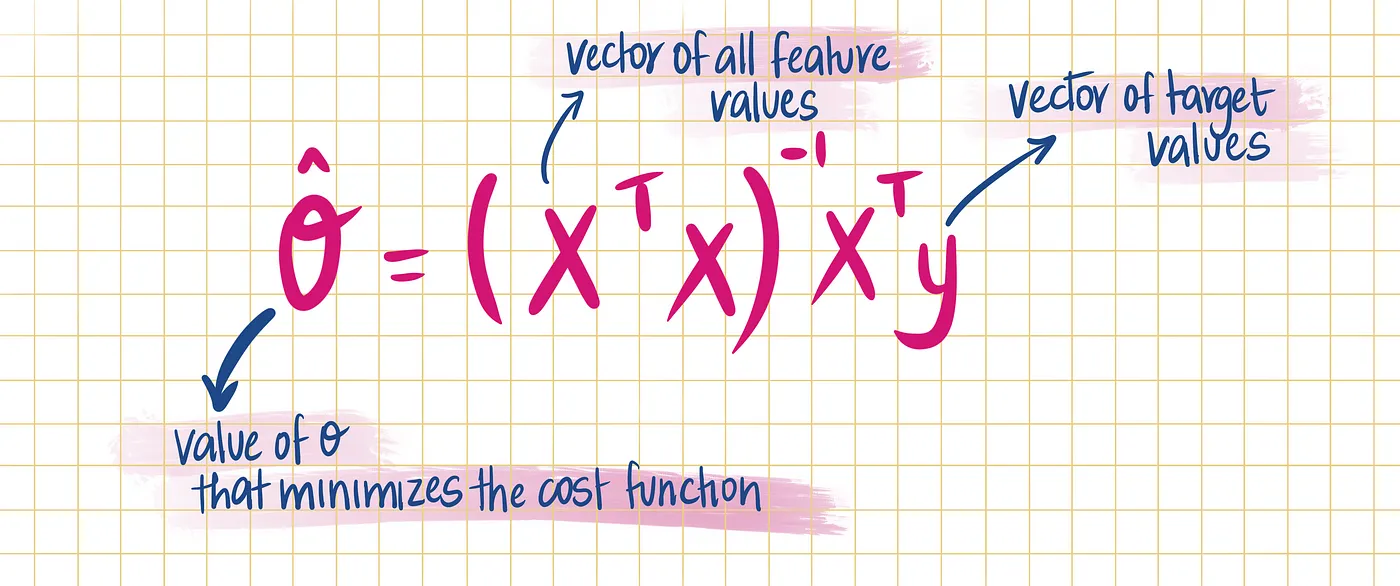


In [7]:
class LinearRegressionClosedFormVector(LinearRegressionBase):
    
    def fit(self, X,Y):
        n = len(Y)
        X_with_b = np.hstack([np.ones((n, 1)), X])

        # Use Pseudo inverse if X is large to make faster
        
        theta = np.linalg.inv(X_with_b.T @ X_with_b) @ X_with_b.T @ Y
        # import pdb; pdb.set_trace()
        self.slope_coeficients = theta[1:]
        self.intersection = theta[0]


run_linear_regression(LinearRegressionClosedFormVector)

"LinearRegressionClosedFormVector" has params [4.121] and 8.374
MSE:       train 52.677, test 45.146
R Squared: train 0.725, test 0.737


In [8]:
class LinearRegressionSGD(LinearRegressionBase):
    def __init__(self):
        self.lr = 0.01
        self.epochs = 1000

    def fit(self, X,Y, verbose=False):

        # dL / dm = -2/n * sum(x(y - y_pred )
        # dL / dc = -2/n * sum(y - y_pred )

        self.slope_coeficients = np.random.randn(X.shape[1])
        self.intersection = np.random.randn()
        n = len(Y)
        for epoch_i in range(self.epochs):
            prediction = self.predict(X)
            loss_derivative = -2/n * (Y - prediction).sum(axis=0)
            dm = X.squeeze().sum() * loss_derivative
            dc = loss_derivative
            self.slope_coeficients -= self.lr * dm
            self.intersection -= self.lr * dc
            if verbose and epoch_i % self.epochs // 10 == 0 or epoch_i == self.epochs-1:
                loss = Metrics.mse(Y, prediction)
                print(f'Loss (mse) at {epoch_i} = {loss:.4f}')

# lin_reg = LinearRegressionSGD()
# lin_reg.fit(X,Y, verbose=True)

run_linear_regression(LinearRegressionClosedFormVector)

"LinearRegressionClosedFormVector" has params [4.121] and 8.374
MSE:       train 52.677, test 45.146
R Squared: train 0.725, test 0.737
